In [1]:
# Step 1: Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [2]:
# Step 2: Load dataset
df = pd.read_csv("water_potability.csv")
print("✅ Data loaded successfully\n")

print("Shape of dataset:", df.shape)
print("\nMissing values per column:\n", df.isnull().sum())
print("\nSample rows:\n", df.head())

✅ Data loaded successfully

Shape of dataset: (3276, 10)

Missing values per column:
 ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

Sample rows:
          ph    Hardness        Solids  Chloramines     Sulfate  Conductivity  \
0       NaN  204.890455  20791.318981     7.300212  368.516441    564.308654   
1  3.716080  129.422921  18630.057858     6.635246         NaN    592.885359   
2  8.099124  224.236259  19909.541732     9.275884         NaN    418.606213   
3  8.316766  214.373394  22018.417441     8.059332  356.886136    363.266516   
4  9.092223  181.101509  17978.986339     6.546600  310.135738    398.410813   

   Organic_carbon  Trihalomethanes  Turbidity  Potability  
0       10.379783        86.990970   2.963135           0  
1       15.180013        56.329076   4.500656          

<Figure size 1200x800 with 0 Axes>

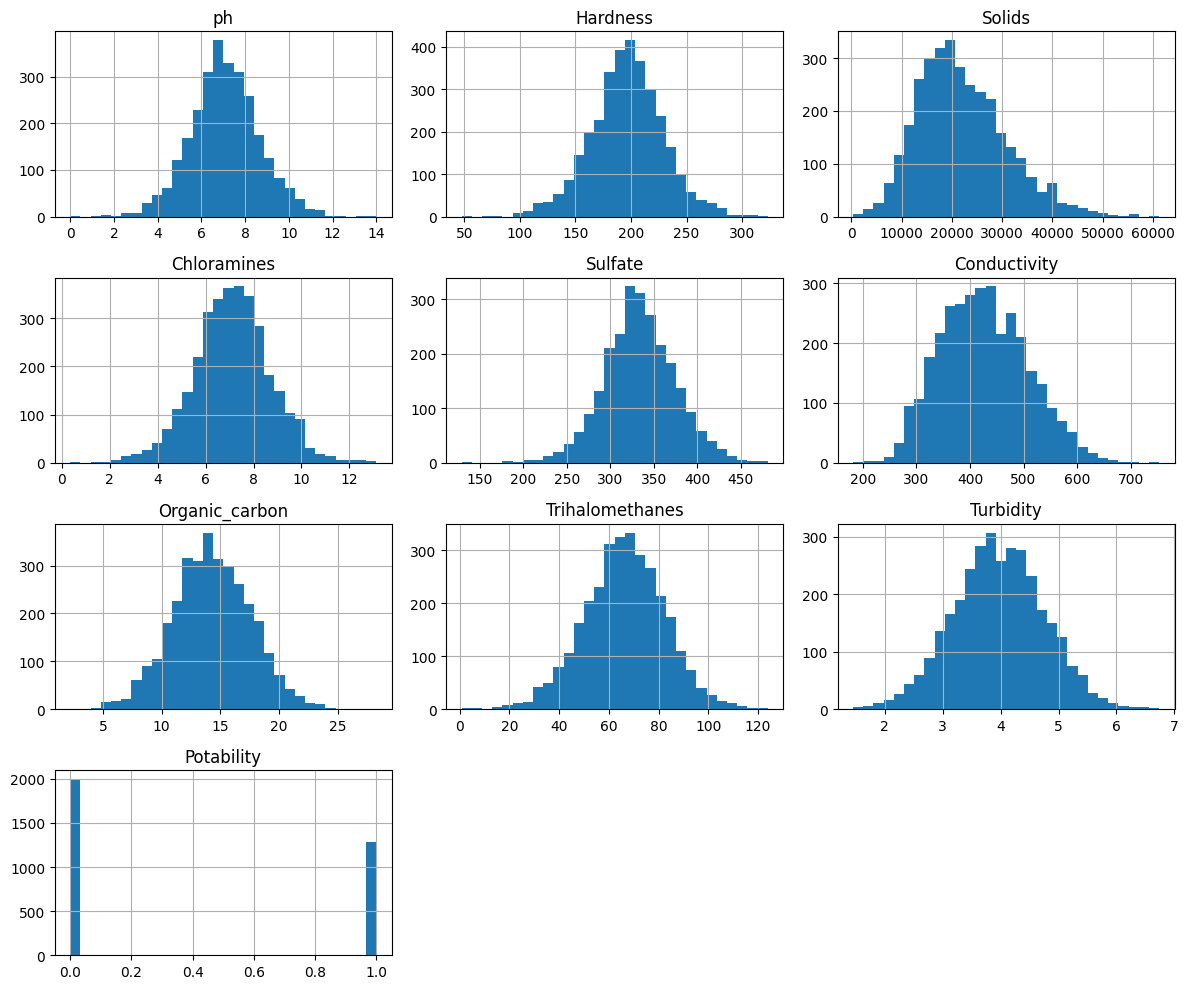

In [10]:
# Visualizations: histograms and correlation heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
df.hist(bins=30, figsize=(12,10))
plt.tight_layout()

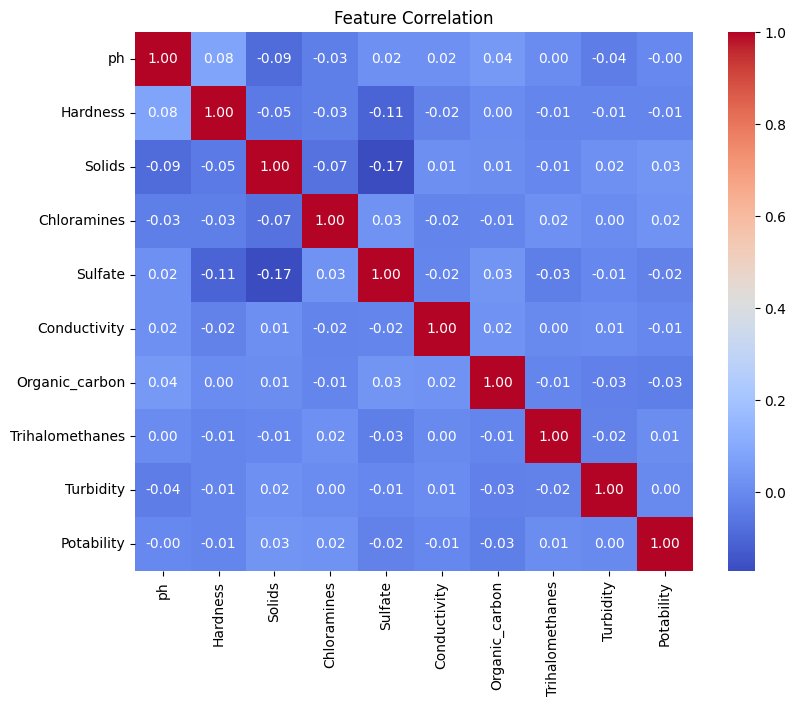

In [11]:
plt.figure(figsize=(9,7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()

In [3]:
# Step 3: Handle missing values (Median Imputation)
imputer = SimpleImputer(strategy='median')
X = df.drop('Potability', axis=1)
y = df['Potability']

X_imputed = imputer.fit_transform(X)
X = pd.DataFrame(X_imputed, columns=X.columns)

print("✅ Missing values handled using median imputation")

✅ Missing values handled using median imputation


In [4]:
# Step 4: Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
print("✅ Feature scaling done")

✅ Feature scaling done


In [5]:
# Step 5: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f"✅ Data split into Train: {X_train.shape} and Test: {X_test.shape}")

✅ Data split into Train: (2620, 9) and Test: (656, 9)


In [6]:
# Step 6: Handle class imbalance with SMOTE
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print("✅ Class imbalance fixed using SMOTE")
print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_res.value_counts().to_dict())

✅ Class imbalance fixed using SMOTE
Before SMOTE: {0: 1598, 1: 1022}
After SMOTE: {0: 1598, 1: 1598}


In [7]:
# Step 7: Train the Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_res, y_train_res)
print("✅ Random Forest model trained successfully")

✅ Random Forest model trained successfully


In [8]:
# Step 8: Evaluate the model
y_pred = rf_model.predict(X_test)
roc_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1])

print("✅ Model evaluation completed\n")
print("Classification Report:\n", classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc)

✅ Model evaluation completed

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.78      0.73       400
           1       0.57      0.46      0.51       256

    accuracy                           0.66       656
   macro avg       0.63      0.62      0.62       656
weighted avg       0.65      0.66      0.65       656

ROC AUC Score: 0.6812158203124999


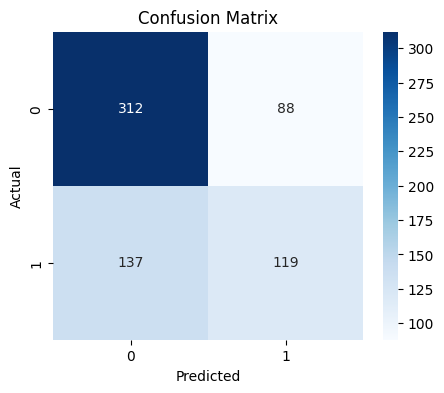

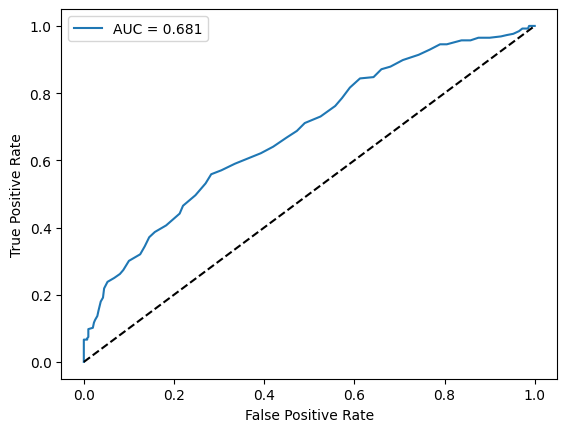

In [13]:
# Confusion matrix & ROC curve
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, confusion_matrix # Import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.show()

y_proba = rf_model.predict_proba(X_test)[:,1] # Define y_proba
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_proba):.3f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.legend(); plt.show()

ph                 0.133277
Sulfate            0.127614
Hardness           0.117476
Chloramines        0.116308
Solids             0.111710
Conductivity       0.100078
Turbidity          0.098399
Organic_carbon     0.097716
Trihalomethanes    0.097423
dtype: float64


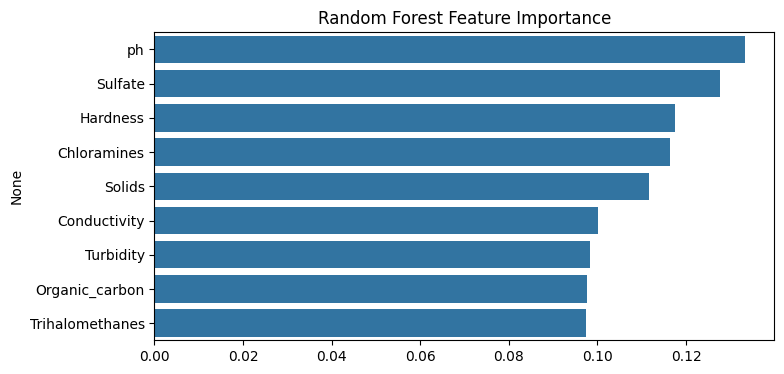

In [15]:
import pandas as pd
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(feat_imp)
plt.figure(figsize=(8,4))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title('Random Forest Feature Importance')
plt.show()

In [9]:
import pickle

# Save trained model
with open("water_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

print("✅ Model saved as water_model.pkl")

✅ Model saved as water_model.pkl
